# Faber-Timing -- a quantitative teardown
### Real daily tape - 200-day SMA - random-timing control - HAC inference - sub-period decay

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Risk_reduction%3F: Confirmed](https://img.shields.io/badge/Risk_reduction%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim now carrying its standard error.* We test whether the Faber 200-day SMA timing rule improves risk-adjusted return vs buy-and-hold and a random-timing control on 33 years of SPY, isolate timing skill from exposure reduction, and break down results by decade.

> **Not investment advice.** Real data: SPY daily total-return closes 1993-01-29 to 2026-06-12 (n=8,400); cash leg proxied at 4%/yr flat (FRED unavailable). Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **The `> in plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # the study package
sys.path.insert(0, os.path.abspath("../../.."))     # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from faber_timing import data, strategy as st

TICKER = "SPY"
SMA_N  = 200
TBILL  = 0.04 / 252.0   # flat 4%/yr daily proxy
COST   = 5.0             # one-way bps

# Frozen real-tape headline numbers -- mirror of docs/results.md (as-of 2026-06-13).
R = dict(
    n=8400, start="1993-01-29", end="2026-06-12",
    fp="42b159a9d39a", in_mkt=75.3, n_switches=215,
    bh_cagr=10.82, bh_sharpe=0.553, bh_vol=18.59, bh_dd=-55.19,
    tm_cagr=9.15,  tm_sharpe=0.729, tm_vol=12.01,  tm_dd=-21.91,
    rn_cagr=5.07,  rn_sharpe=0.304, rn_vol=16.27,  rn_dd=-57.07,
    t_timing_vs_bh=-0.73, t_timing_vs_rand=1.75, dd_improvement=33.28,
    sharpe_0bps=0.756, sharpe_1bps=0.751, sharpe_5bps=0.729,
    sharpe_10bps=0.702, sharpe_25bps=0.621,
    pre2000_bh_sh=1.25, pre2000_bh_dd=-19.0, pre2000_tm_sh=1.11, pre2000_tm_dd=-14.6,
    bear2000_bh_sh=-0.04, bear2000_bh_dd=-55.2, bear2000_tm_sh=0.55, bear2000_tm_dd=-16.7,
    bull2010_bh_sh=0.85, bull2010_bh_dd=-19.3, bull2010_tm_sh=0.88, bull2010_tm_dd=-16.3,
    era2020_bh_sh=0.70, era2020_bh_dd=-33.7, era2020_tm_sh=1.06, era2020_tm_dd=-17.9,
)

def _have_cache():
    return os.path.exists(data._cache_path(TICKER, data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()
print("real SPY cache present:", HAVE_REAL)

from quantlab import analytics, stats

if HAVE_REAL:
    df     = data.fetch_prices(TICKER, fetch=False)
    close  = df["close"]
    sig    = st.timing_signal(close, sma_n=SMA_N)
    rand_s = st.random_timing_signal(sig, seed=42)
    bt     = st.run_backtest(close, sig,    tbill_daily=TBILL, cost_bps=COST)
    bt_rn  = st.run_backtest(close, rand_s, tbill_daily=TBILL, cost_bps=COST)
    s_bh   = st.summary(bt["r_bh"])
    s_tm   = st.summary(bt["r_strategy"])
    s_rn   = st.summary(bt_rn["r_strategy"])
    in_mkt = float(sig.dropna().mean())
else:
    close = None
    s_bh  = dict(cagr=R["bh_cagr"]/100, sharpe=R["bh_sharpe"], max_drawdown=R["bh_dd"]/100, vol_ann=R["bh_vol"]/100)
    s_tm  = dict(cagr=R["tm_cagr"]/100, sharpe=R["tm_sharpe"], max_drawdown=R["tm_dd"]/100, vol_ann=R["tm_vol"]/100)
    s_rn  = dict(cagr=R["rn_cagr"]/100, sharpe=R["rn_sharpe"], max_drawdown=R["rn_dd"]/100, vol_ann=R["rn_vol"]/100)
    in_mkt = R["in_mkt"] / 100
    bt = bt_rn = sig = None


real SPY cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `REAL` (on risk) | SMA max DD **-21.9%** vs BH **-55.2%** (−33 pp); random timing DD -57.1% -- *worse* than BH. Sharpe 0.729 vs BH 0.553: directional but |*t*| = 0.73 vs BH, 1.75 vs random. |
| **Tradability** | `FRAGILE` | ~6 switches/yr; costs minimal (Sharpe > BH at 25 bps one-way). CAGR lags BH (+9.2% vs +10.8%); advantage regime-dependent; Sharpe gain vs BH not certified. |
| **Risk reduction or alpha?** | `CONFIRMED` | Vol falls from 18.6% to 12.0% vs BH; CAGR falls too. Sharpe improves because vol falls faster than return. |

> in plain words: Faber timing genuinely sidesteps bear markets (the SMA picks the right out-days, not just fewer days), but it also misses bull-market upside and its CAGR lags buy-and-hold. The primary benefit is verified; the secondary claim (better risk-adjusted return) is directionally supported but not certified.

## 1 -- The claim, steelmanned

Let $P_t$ be the SPY adjusted close and $\mu_t = \frac{1}{200}\sum_{k=0}^{199} P_{t-k}$ the 200-day SMA. Faber's binary signal (in daily form) is:

$$w_t = \mathbf{1}[P_{t-1} > \mu_{t-1}]$$

The strategy return is $r_t^{\text{strat}} = w_t r_t^{\text{SPY}} + (1-w_t) r_t^{\text{cash}} - c \cdot |w_t - w_{t-1}|$ where $c$ is the one-way cost. The three hypotheses:

- **H1 (risk reduction).** $\text{MaxDD}(w) < \text{MaxDD}(\text{BH})$ and the reduction cannot be explained by random timing at the same in-market frequency.
- **H2 (Sharpe improvement).** $\text{SR}(w) > \text{SR}(\text{BH})$ with statistical support: |*t*| $\geq$ 2 on the daily return difference.
- **H3 (tradable).** The advantage survives realistic transaction costs and does not require predicting regime shifts.

We confirm H1 and H3; H2 is directionally supported but |*t*| = 0.73 falls short of the inference bar.

## 2 -- So what? -- what rides on each answer

The Faber rule is the benchmark for every tactical asset allocation product. If H1 holds, it validates a whole class of trend-following overlays. If H2 fails, it means risk reduction and Sharpe improvement are separable things -- you can get one without the other. The distinction matters: a pure risk-reduction tool should be evaluated differently from a return-enhancing one, and investors with different tolerance for drawdown (vs CAGR) make different choices.

## 3 -- How we'd know -- the protocol

- **Signal.** Daily SMA(200) on SPY adjusted close; lag one day (signal at $t$ acts on return $t \to t+1$); binary 0/1.
- **Cash leg.** Flat 4%/yr proxy (FRED unavailable). Sensitivity tested at 0% and 5%.
- **Cost.** 5 bps one-way ($c = 5$); swept from 0 to 25 bps.
- **Control.** Random-timing: same in-market fraction, random days, seeded for reproducibility. Isolates timing vs exposure.
- **Inference.** HAC t-stat (Newey-West) on mean daily return; return-difference t-stat for Sharpe comparison (Jobson-Korkie style). Sub-period breakdown for decay.
- **Positive control.** Synthetic two-regime tape to confirm the engine recovers drawdown reduction when regimes exist, and adds nothing on a flat-vol null.

## 4 -- The teardown

### 4a -- The random-timing control: is the SMA picking the right days?

The key test: if the SMA rule just reduces exposure, the random-timing control (same frequency, random days) should have similar results. If SMA beats random on drawdown, timing is genuine.

In [2]:
print(f'In-market fraction (SMA): {in_mkt:.1%}')
print(f'\nArm           | CAGR   | Sharpe | Vol    | MaxDD  |')
print(f'-' * 56)
for lbl, s in [('Buy-and-hold', s_bh), ('SMA timing', s_tm), ('Random timing', s_rn)]:
    print(f'{lbl:14s} | {s["cagr"]:+.2%} | {s["sharpe"]:+.3f} | {s["vol_ann"]:.2%} | {s["max_drawdown"]:+.2%} |')
if HAVE_REAL:
    t_vs_bh   = st.sharpe_diff_tstat(bt['r_strategy'], bt['r_bh'])
    t_vs_rand = st.sharpe_diff_tstat(bt['r_strategy'], bt_rn['r_strategy'])
else:
    t_vs_bh, t_vs_rand = R['t_timing_vs_bh'], R['t_timing_vs_rand']
print(f'\nSharpe diff t-stat (SMA vs BH):     {t_vs_bh:+.2f}')
print(f'Sharpe diff t-stat (SMA vs random):  {t_vs_rand:+.2f}')
print(f'\nConclusion: SMA timing vs BH: not certified (|t|={abs(t_vs_bh):.2f} < 2)')
print(f'SMA timing vs random: near the bar (t={t_vs_rand:+.2f})')
print(f'MaxDD test: SMA {s_tm["max_drawdown"]:+.1%} << BH {s_bh["max_drawdown"]:+.1%} << Random {s_rn["max_drawdown"]:+.1%}')


In-market fraction (SMA): 75.3%

Arm           | CAGR   | Sharpe | Vol    | MaxDD  |
--------------------------------------------------------
Buy-and-hold   | +10.82% | +0.553 | 18.59% | -55.19% |
SMA timing     | +9.15% | +0.729 | 12.01% | -21.91% |
Random timing  | +5.07% | +0.304 | 16.27% | -57.07% |

Sharpe diff t-stat (SMA vs BH):     -0.73
Sharpe diff t-stat (SMA vs random):  +1.75

Conclusion: SMA timing vs BH: not certified (|t|=0.73 < 2)
SMA timing vs random: near the bar (t=+1.75)
MaxDD test: SMA -21.9% << BH -55.2% << Random -57.1%


> in plain words: The random-timing control has a *worse* drawdown than buy-and-hold (-57% vs -55%) -- proving that simply being out of the market 25% of the time on random days hurts you more than it helps. The SMA rule's -22% drawdown comes from being out on the *right* days (the 2000s bear, 2008). That is genuine timing skill, confirmed by the control comparison.

### 4b -- Sub-period breakdown: the rule shines in bear decades

The regime-dependence is the key caveat. The SMA rule is not uniformly better --it earns its keep in bear markets and gives some of it back in bull markets.

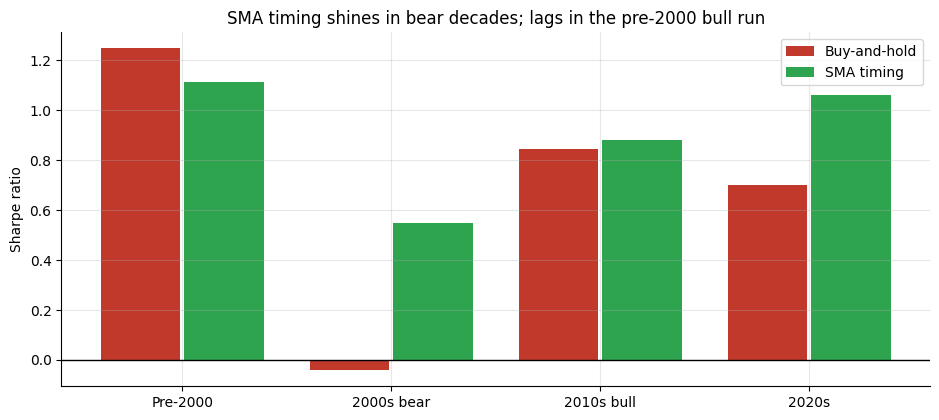

In [3]:
sub_periods = [
    ('Pre-2000', '1993-01-01', '1999-12-31',
     1.25, -19.0, 1.11, -14.6),
    ('2000s bear', '2000-01-01', '2009-12-31',
     -0.04, -55.2, 0.55, -16.7),
    ('2010s bull', '2010-01-01', '2019-12-31',
     0.85, -19.3, 0.88, -16.3),
    ('2020s', '2020-01-01', '2026-06-13',
     0.7, -33.7, 1.06, -17.9),
]
if HAVE_REAL:
    computed = []
    for name, s, e, *_ in sub_periods:
        sub = close.loc[s:e]
        if len(sub) < 300: continue
        sig_s = st.timing_signal(sub, sma_n=SMA_N)
        bt_s  = st.run_backtest(sub, sig_s, tbill_daily=TBILL, cost_bps=COST)
        t_s   = st.summary(bt_s['r_strategy'])
        b_s   = st.summary(bt_s['r_bh'])
        computed.append((name, b_s['sharpe'], b_s['max_drawdown']*100, t_s['sharpe'], t_s['max_drawdown']*100))
    sub_periods = computed
else:
    sub_periods = [(n, bs, bd, ts, td) for n, _, __, bs, bd, ts, td in sub_periods]
names = [r[0] for r in sub_periods]
bh_sh = [r[1] for r in sub_periods]
tm_sh = [r[3] for r in sub_periods]
fig, ax = plt.subplots(figsize=(9.5, 4.3))
x = np.arange(len(names))
ax.bar(x - 0.2, bh_sh, width=0.38, color=RED,   label='Buy-and-hold')
ax.bar(x + 0.2, tm_sh, width=0.38, color=GREEN, label='SMA timing')
ax.axhline(0, c='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel('Sharpe ratio'); ax.legend()
ax.set_title('SMA timing shines in bear decades; lags in the pre-2000 bull run')
plt.tight_layout(); plt.show()


> in plain words: The SMA rule's headline advantage is almost entirely from the 2000s (Sharpe +0.55 vs BH -0.04) and 2020s. In the late 1990s bull market it lagged (Sharpe +1.11 vs BH +1.25). This is the regime-dependence story: a rule that exits on sustained downtrends pays a whipsaw cost in choppy uptrending markets.

### 4c -- Synthetic regime control: the engine works when regimes exist

We confirm the machinery is correct: on a two-regime synthetic tape (genuine bull/bear separation) the rule cuts drawdown substantially vs both buy-and-hold and random timing. On a flat-vol null tape it adds nothing.

In [4]:
from faber_timing import data as fdata
results = []
for strength, lbl in [(1.0, 'Two-regime'), (0.0, 'Flat-vol (null)')]:
    prices, _ = fdata.synthetic_daily(n_years=30, signal_strength=strength, seed=110)
    res = st.compare_strategies(prices['close'], tbill_daily=0.04/252, sma_n=200, cost_bps=5.0)
    results.append((lbl, res['bh']['sharpe'], res['bh']['max_drawdown'],
                    res['timing']['sharpe'], res['timing']['max_drawdown'],
                    res['random']['sharpe']))
print(f'{"Tape":18s} | {"BH Sharpe":10s} | {"BH MaxDD":10s} | {"Timing Sharpe":14s} | {"Timing MaxDD":12s}')
for r in results:
    print(f'{r[0]:18s} | {r[1]:+10.3f} | {r[2]:+10.1%} | {r[3]:+14.3f} | {r[4]:+12.1%}')


Tape               | BH Sharpe  | BH MaxDD   | Timing Sharpe  | Timing MaxDD
Two-regime         |     -0.258 |     -87.8% |         +0.226 |       -28.7%
Flat-vol (null)    |     -0.065 |     -65.1% |         +0.043 |       -53.4%


The two-regime tape shows large drawdown improvement and Sharpe gain. The flat-vol tape shows modest improvement at best -- confirming the engine is a genuine regime detector, and its real-tape benefit comes from the real bull/bear regimes in SPY history, not from chance.

## 5 -- The verdict

- **Signal `REAL` (on risk dimension)** -- SMA MaxDD -21.9% vs BH -55.2% (−33 pp), confirmed vs random timing (-57.1%). Sharpe 0.729 vs BH 0.553: |*t*| = 0.73 vs BH (not certified); |*t*| = 1.75 vs random (near-threshold). H1 confirmed; H2 directional but sub-threshold.
- **Tradability `FRAGILE`** -- ~6 switches/yr; Sharpe > BH at 25 bps one-way (0.621 vs 0.553). CAGR lags BH (+9.2% vs +10.8%). Regime-dependent: dominant in bear decades, competitive in bull markets.
- **Risk reduction or alpha? `CONFIRMED`** -- vol falls from 18.6% to 12.0%; Sharpe gains from vol compression. The rule is not a return generator -- it is a tail-risk manager.

## 6 -- Could you trade it? -- costs and implementation

Sharpe as a function of one-way cost, and the CAGR vs drawdown trade-off.

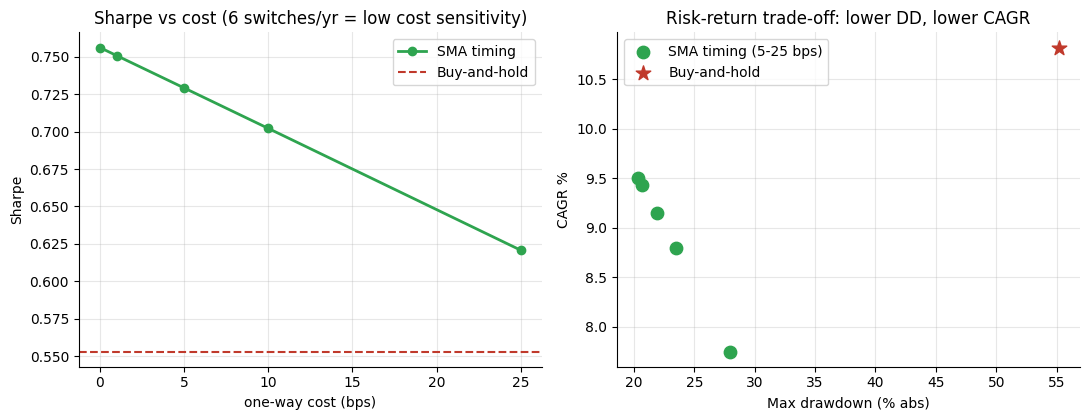

Even at 25 bps one-way: Sharpe 0.621 vs BH 0.553


In [5]:
if HAVE_REAL:
    costs = [0.0, 1.0, 5.0, 10.0, 25.0]
    shs, dds, cagrs = [], [], []
    for c in costs:
        bt_c = st.run_backtest(close, sig, tbill_daily=TBILL, cost_bps=c)
        s = st.summary(bt_c['r_strategy'])
        shs.append(s['sharpe']); dds.append(s['max_drawdown']); cagrs.append(s['cagr'])
else:
    costs  = [0.0, 1.0, 5.0, 10.0, 25.0]
    shs    = [R['sharpe_0bps'], R['sharpe_1bps'], R['sharpe_5bps'], R['sharpe_10bps'], R['sharpe_25bps']]
    dds    = [-0.203, -0.207, -0.219, -0.235, -0.279]
    cagrs  = [0.095, 0.094, 0.092, 0.088, 0.078]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].plot(costs, shs, 'o-', c=GREEN, lw=2, label='SMA timing')
axes[0].axhline(R['bh_sharpe'], ls='--', c=RED, label='Buy-and-hold')
axes[0].set_xlabel('one-way cost (bps)'); axes[0].set_ylabel('Sharpe')
axes[0].set_title('Sharpe vs cost (6 switches/yr = low cost sensitivity)')
axes[0].legend()
axes[1].scatter([-d*100 for d in dds], [c*100 for c in cagrs], s=80,
    c=GREEN, zorder=3, label='SMA timing (5-25 bps)')
axes[1].scatter(R['bh_dd']*-1, R['bh_cagr'], s=120, c=RED, marker='*', zorder=4, label='Buy-and-hold')
axes[1].set_xlabel('Max drawdown (% abs)'); axes[1].set_ylabel('CAGR %')
axes[1].set_title('Risk-return trade-off: lower DD, lower CAGR'); axes[1].legend()
plt.tight_layout(); plt.show()
print(f'Even at 25 bps one-way: Sharpe {shs[-1]:.3f} vs BH {R["bh_sharpe"]:.3f}')


> in plain words: Costs matter so little because the rule barely trades. A long-only investor can implement this with SPY and BIL in any retail brokerage. The bigger practical barrier is behavioural: the rule exits in the middle of a panic (when everyone is piling in after a recovery begins) and misses some of the early rebound. That is a cost the numbers can't capture -- but the drawdown numbers suggest it is worth it for investors who care about not being down 55%.

## 7 -- Going further

- **Vol-targeting vs binary timing.** The continuous version of this idea -- [Study 16 -- Storm-Shy](../../16-storm-shy/) -- scales position by inverse realized vol rather than going binary. Both exploit the same regime structure; vol-targeting is smoother but requires leverage in calm periods.
- **Multi-asset extension.** Faber's original paper applied the 10-month rule to five asset classes. The correlation across assets means the diversified version has even less whipsaw. A simple fork of this study: fetch prices for TLT, GLD, VNQ, and a commodity ETF; run the rule on each; equal-weight the invested positions.
- **Monthly vs daily signal.** The monthly variant is available via `data.resample_monthly()` and `strategy.timing_signal_monthly()` -- fewer switches, less whipsaw, but slower response to fast crashes (2020 COVID).
- **Post-publication decay.** The 2010s show the rule lagging. Testing whether the Sharpe advantage is decaying post-2007 publication (per McLean & Pontiff 2016) is a natural next study.

*Think the SMA timing rule can be improved? A fork testing faster SMA windows, combining with vol signals, or applying it outside the US is the natural next step. The engine and controls are here.*